RFM Segmentation and Data Visulization.

In [1]:
import pandas as pd #-----> imported libraries.
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Zudio_Cleaned_Data.csv to Zudio_Cleaned_Data.csv


In [3]:
df = pd.read_csv("Zudio_Cleaned_Data.csv")

In [4]:
import pandas as pd
df = pd.read_csv("Zudio_Cleaned_Data.csv")

In [5]:
df.head()

,State,City,Category,Clothing Type,Store Number,Store Type,Store Open Date,Selling Area Size (sq ft),Staff Count,Order ID,...,Sales Profit,Profit Status,Profit Margin,Cost,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27
0,Karnataka,Jalna,Women,Dresses,30,Owned,06-04-2022,950,17,88240,...,"3,916",Low Profit,40%,"5,874",NaN,NaN,NaN,NaN,NaN,NaN
1,Gujarat,Patna,Kids,Skirts,48,Owned,19-12-2020,1200,6,78145,...,831,Low Profit,40%,"1,247",NaN,NaN,NaN,NaN,NaN,NaN
2,Uttar Pradesh,Kolkata,Men,Hoodies,97,Rented,09-04-2023,1100,18,33363,...,"1,156",Low Profit,40%,"1,734",NaN,NaN,NaN,NaN,NaN,NaN
3,West Bengal,Kolkata,Women,Dresses,93,Owned,04-11-2024,1400,13,46682,...,"5,926",High Profit,40%,"8,888",NaN,NaN,NaN,NaN,CALCULATIONS,NaN
4,West Bengal,Guwahati,Men,Dresses,51,Owned,29-05-2022,1400,19,58242,...,"2,652",Low Profit,40%,"3,978",NaN,NaN,NaN,TOTAL REVENUE,NaN,"62,612,833"


In [6]:
# Remove columns whose name starts with "Unnamed"
df = df.loc[:, ~df.columns.str.startswith('Unnamed')]

# Check the columns again
print(df.columns)

Index(['State', 'City', 'Category', 'Clothing Type', 'Store Number',
       'Store Type', 'Store Open Date', 'Selling Area Size (sq ft)',
       'Staff Count', 'Order ID', 'Order Date', 'Month', 'Customer ID',
       'Product ID', '  Price  ', 'Quantity', ' Sales revenue ',
       'Revenue Catergory', ' Sales Profit ', 'Profit Status', 'Profit Margin',
       ' Cost '],
      dtype='object')


In [7]:
print("Rows:", df.shape[0]) #-----> checked rows and columns
print("Columns:", df.shape[1])

Rows: 7899
Columns: 22


In [8]:
df = df.dropna(axis=1, how='all') #----> removed blank columns

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 7899
Columns: 22


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7899 entries, 0 to 7898
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   State                      7899 non-null   object
 1   City                       7899 non-null   object
 2   Category                   7899 non-null   object
 3   Clothing Type              7899 non-null   object
 4   Store Number               7899 non-null   int64 
 5   Store Type                 7899 non-null   object
 6   Store Open Date            7899 non-null   object
 7   Selling Area Size (sq ft)  7899 non-null   int64 
 8   Staff Count                7899 non-null   int64 
 9   Order ID                   7899 non-null   int64 
 10  Order Date                 7899 non-null   object
 11  Month                      7899 non-null   object
 12  Customer ID                7899 non-null   int64 
 13  Product ID                 7899 non-null   int64 
 14    Price 

In [10]:
print(df.columns.tolist()) #----> checked columns for extra spaces

['State', 'City', 'Category', 'Clothing Type', 'Store Number', 'Store Type', 'Store Open Date', 'Selling Area Size (sq ft)', 'Staff Count', 'Order ID', 'Order Date', 'Month', 'Customer ID', 'Product ID', '  Price  ', 'Quantity', ' Sales revenue ', 'Revenue Catergory', ' Sales Profit ', 'Profit Status', 'Profit Margin', ' Cost ']


In [11]:
# Remove extra spaces from column names
df.columns = df.columns.astype(str).str.strip()

# Remove extra spaces from column names
df.columns = df.columns.astype(str).str.strip()

In [13]:
df['Order Date'] = pd.to_datetime(
    df['Order Date'],
    format='%d-%m-%Y'
)

In [14]:
# Convert numeric columns
numeric_columns = [
    'Price',
    'Quantity',
    'Sales revenue',
    'Sales Profit',
    'Cost'
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("Data types:")
print(df.dtypes)
df.columns = df.columns.astype(str).str.strip()

Data types:
State                                object
City                                 object
Category                             object
Clothing Type                        object
Store Number                          int64
Store Type                           object
Store Open Date                      object
Selling Area Size (sq ft)             int64
Staff Count                           int64
Order ID                              int64
Order Date                   datetime64[ns]
Month                                object
Customer ID                           int64
Product ID                            int64
Price                               float64
Quantity                              int64
Sales revenue                       float64
Revenue Catergory                    object
Sales Profit                        float64
Profit Status                        object
Profit Margin                        object
Cost                                float64
dtype: object


In [15]:
# Basic Statistics
df[['Price', 'Quantity', 'Sales revenue', 'Sales Profit']].describe()

,Price,Quantity,Sales revenue,Sales Profit
count,1546.000000,7899.000000,201.000000,1230.000000
mean,750.862872,4.519433,736.815920,660.969919
std,144.159389,2.292373,146.380501,223.914886
min,499.000000,1.000000,501.000000,200.000000
25%,627.000000,3.000000,605.000000,484.250000
50%,751.500000,5.000000,731.000000,693.000000
75%,873.750000,7.000000,859.000000,851.750000
max,999.000000,8.000000,999.000000,999.000000


In [16]:
# RFM Analysis ----> R — Recency, F — Frequency, M — Monetary.

analysis_date = df['Order Date'].max() #----> set analysis using date

print("Analysis Date:", analysis_date)

Analysis Date: 2024-12-11 00:00:00


In [17]:
rfm = df.groupby('Customer ID').agg(     # -----> RFM table
    Recency=('Order Date',
             lambda x: (analysis_date - x.max()).days),

    Frequency=('Order ID', 'nunique'),

    Monetary=('Sales revenue', 'sum')
).reset_index()

rfm.head()

,Customer ID,Recency,Frequency,Monetary
0,100153,106,1,654.0
1,100263,263,1,0.0
2,100271,289,1,0.0
3,100430,199,1,0.0
4,100508,320,1,0.0


In [19]:
rfm.shape
rfm[['Recency', 'Frequency', 'Monetary']].describe()

,Recency,Frequency,Monetary
count,7870.000000,7870.000000,7870.000000
mean,173.414485,1.003685,18.818297
std,100.166019,0.060595,118.565631
min,0.000000,1.000000,0.000000
25%,87.000000,1.000000,0.000000
50%,174.000000,1.000000,0.000000
75%,261.000000,1.000000,0.000000
max,345.000000,2.000000,999.000000


In [20]:
## RFM Score.
rfm['R_Score'] = pd.qcut(  # ---> Recency
    rfm['Recency'].rank(method='first'),
    5,
    labels=[5,4,3,2,1]
).astype(int)

rfm['F_Score'] = np.where( #---> Frequency
    rfm['Frequency'] >= 2,
    5,
    1
)

rfm['M_Score'] = pd.qcut(  #----> Monetary
    rfm['Monetary'].rank(method='first'),
    5,
    labels=[1,2,3,4,5]
).astype(int)

rfm['RFM_Score'] = (   #----> RFM calculation
    rfm['R_Score'] +
    rfm['F_Score'] +
    rfm['M_Score']
)

rfm.head(10)

,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,100153,106,1,654.0,4,1,5,10
1,100263,263,1,0.0,2,1,1,4
2,100271,289,1,0.0,1,1,1,3
3,100430,199,1,0.0,3,1,1,5
4,100508,320,1,0.0,1,1,1,3
5,100597,117,1,0.0,4,1,1,6
6,100616,97,1,0.0,4,1,1,6
7,100701,208,1,0.0,3,1,1,5
8,100792,17,1,0.0,5,1,1,7
9,100956,80,1,0.0,4,1,1,6


In [21]:
## Customer Segmentation.
def segment_customer(row):

    r = row['R_Score']
    f = row['F_Score']
    m = row['M_Score']

    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'

    elif r >= 3 and f >= 4:
        return 'Loyal Customers'

    elif r >= 4 and f <= 2:
        return 'New Customers'

    elif r <= 2 and m >= 4:
        return 'At Risk'

    elif r <= 2 and m <= 2:
        return 'Lost Customers'

    else:
        return 'Potential Loyalists'


rfm['Segment'] = rfm.apply(segment_customer, axis=1)

In [22]:
## Return Segment result as
segment_summary = (
    rfm.groupby('Segment')
    .agg(
    Customers=('Customer ID', 'count'),
    Total_Revenue=('Monetary', 'sum'),
    Average_Revenue=('Monetary', 'mean'),
    Average_Recency=('Recency', 'mean'),
    Average_Frequency=('Frequency', 'mean')
    )
    .reset_index()
    .sort_values('Total_Revenue', ascending=False)
)
segment_summary.round(2)

,Segment,Customers,Total_Revenue,Average_Revenue,Average_Recency,Average_Frequency
0,At Risk,1251,64117.0,51.25,277.15,1.0
4,New Customers,3131,52568.0,16.79,68.97,1.0
5,Potential Loyalists,2209,30069.0,13.61,203.85,1.0
1,Champions,9,1346.0,149.56,75.78,2.0
3,Loyal Customers,14,0.0,0.00,121.79,2.0
2,Lost Customers,1256,0.0,0.00,278.21,1.0


Data Visualization.

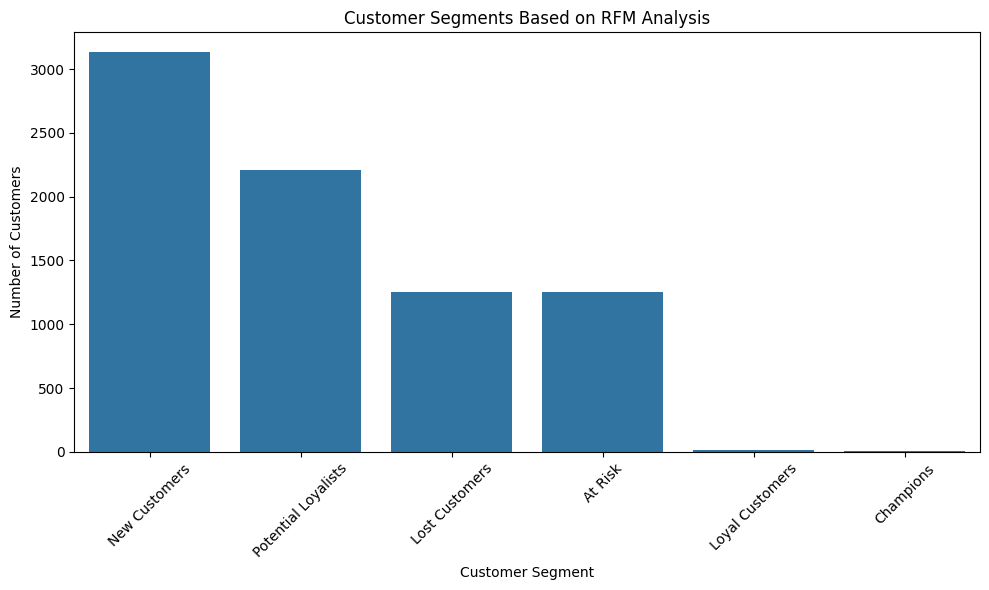

In [23]:
## Bar Chart
plt.figure(figsize=(10,6))


sns.countplot(
    data=rfm,
    x='Segment',
    order=rfm['Segment'].value_counts().index
)

plt.title('Customer Segments Based on RFM Analysis')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [24]:
## Monthly Revenue
monthly_sales = df.groupby('Month').agg(
    Revenue=('Sales revenue', 'sum'),
    Profit=('Sales Profit', 'sum')
).reset_index()

monthly_sales = (
    df.assign(Month_Date=df['Order Date'].dt.to_period('M').dt.to_timestamp())
      .groupby('Month_Date')
      .agg(
          Revenue=('Sales revenue', 'sum'),
          Profit=('Sales Profit', 'sum')
      )
      .reset_index()
)

monthly_sales

,Month_Date,Revenue,Profit
0,2024-01-01,14771.0,68041.0
1,2024-02-01,13195.0,67037.0
2,2024-03-01,17498.0,77646.0
3,2024-04-01,11850.0,59729.0
4,2024-05-01,15199.0,85880.0
5,2024-06-01,11241.0,64705.0
6,2024-07-01,12752.0,75770.0
7,2024-08-01,10878.0,60000.0
8,2024-09-01,9170.0,62042.0
9,2024-10-01,13784.0,99349.0


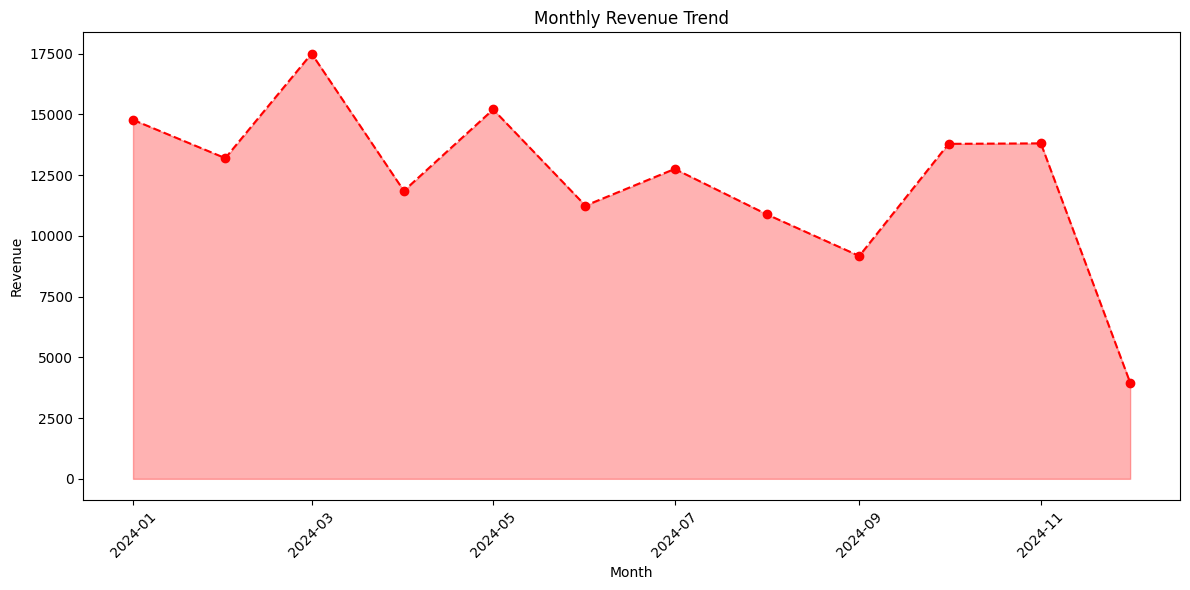

In [25]:
## Line chart
plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales['Month_Date'], monthly_sales['Revenue'], marker='o', linestyle='--', color='red')
plt.fill_between(
    monthly_sales['Month_Date'], monthly_sales['Revenue'],color='red', alpha=0.3)

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [26]:
## category revenue
category_summary = df.groupby('Category').agg(
    Revenue=('Sales revenue', 'sum'),
    Profit=('Sales Profit', 'sum'),
    Quantity=('Quantity', 'sum')
).reset_index()

category_summary

,Category,Revenue,Profit,Quantity
0,Kids,67187.0,263463.0,12013
1,Men,45860.0,281645.0,11727
2,Women,35053.0,267885.0,11959


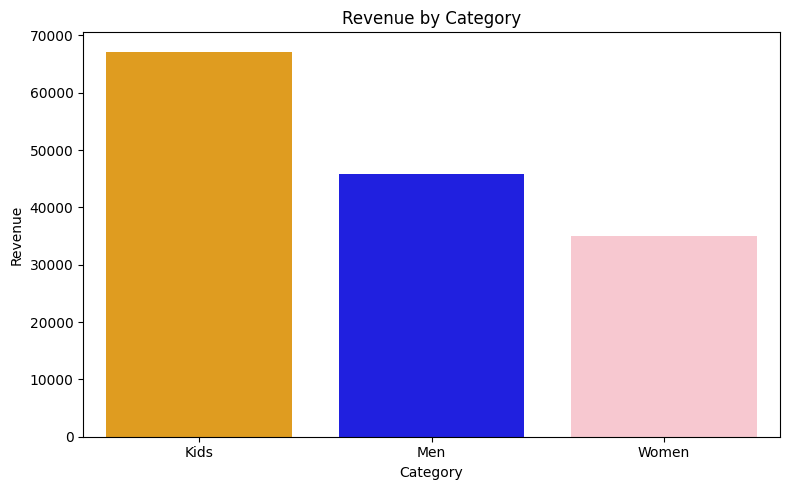

In [28]:
plt.figure(figsize=(8,5))

colors = {
    'Women': 'pink',
    'Men': 'blue',
    'Kids': 'orange'
}

sns.barplot(
    data=category_summary,
    x='Category',
    y='Revenue',
    hue='Category',
    palette=colors,
    legend=False
)

plt.title('Revenue by Category')
plt.xlabel('Category')
plt.ylabel('Revenue')

plt.tight_layout()
plt.show()

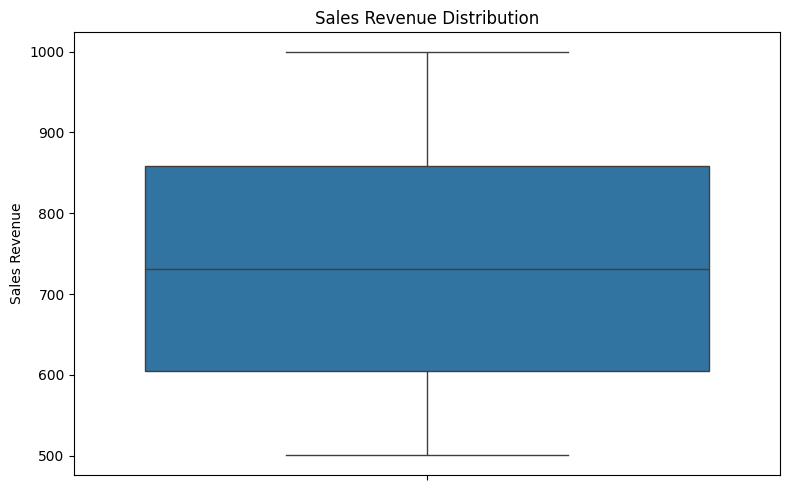

In [29]:
## Revenue distribution by sales
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    y='Sales revenue'
)

plt.title('Sales Revenue Distribution')
plt.ylabel('Sales Revenue')
plt.tight_layout()
plt.show()

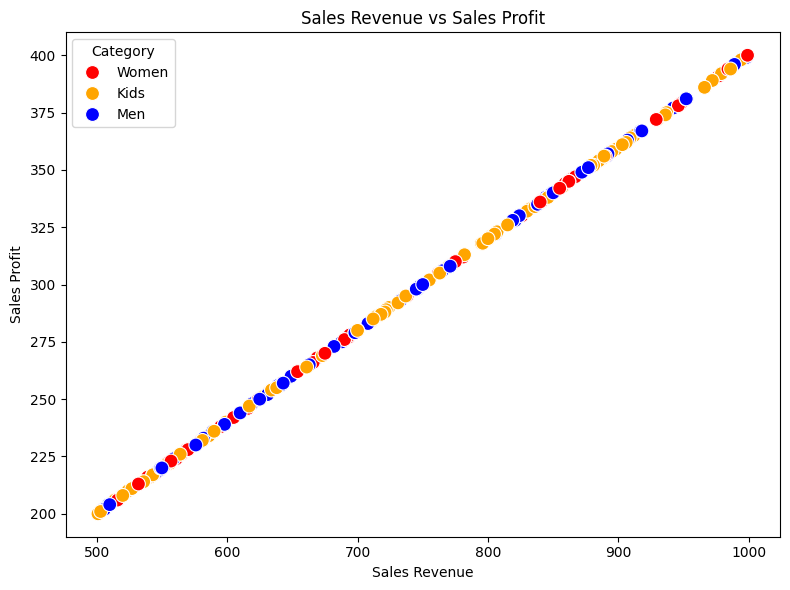

In [35]:
## Scatter Plot
plt.figure(figsize=(8,6))

colors = {
    'Men': 'blue',
    'Women': 'red',
    'Kids': 'orange'
}

sns.scatterplot(
    data=df,
    x='Sales revenue',
    y='Sales Profit',
    hue='Category',
    palette=colors,
    s=100
)

plt.title('Sales Revenue vs Sales Profit')
plt.xlabel('Sales Revenue')
plt.ylabel('Sales Profit')

plt.tight_layout()
plt.show()

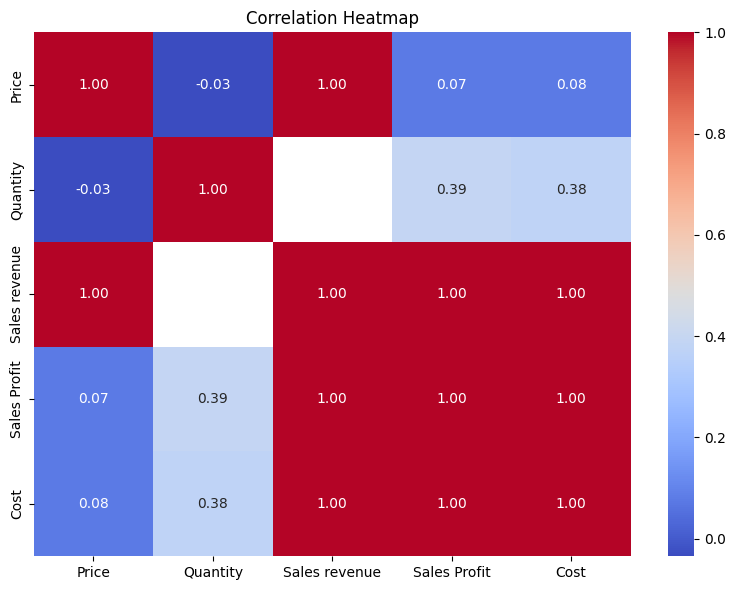

In [37]:
## Correlation Heatmap
numeric_columns = [
    'Price',
    'Quantity',
    'Sales revenue',
    'Sales Profit',
    'Cost'
]

correlation = df[numeric_columns].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

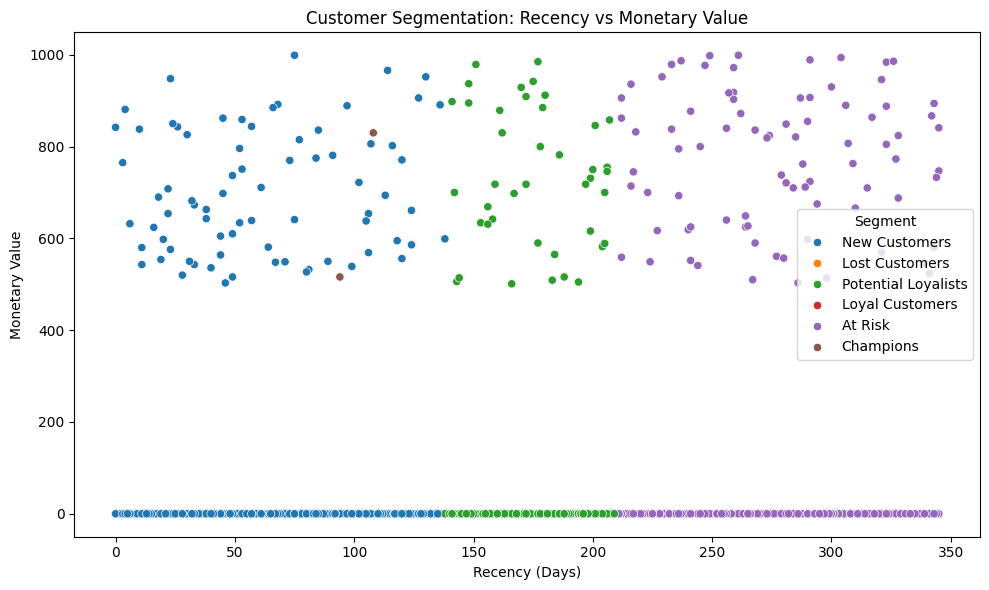

In [39]:
## RFM scatter plot
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Segment'
)

plt.title('Customer Segmentation: Recency vs Monetary Value')
plt.xlabel('Recency (Days)')
plt.ylabel('Monetary Value')
plt.tight_layout()
plt.show()

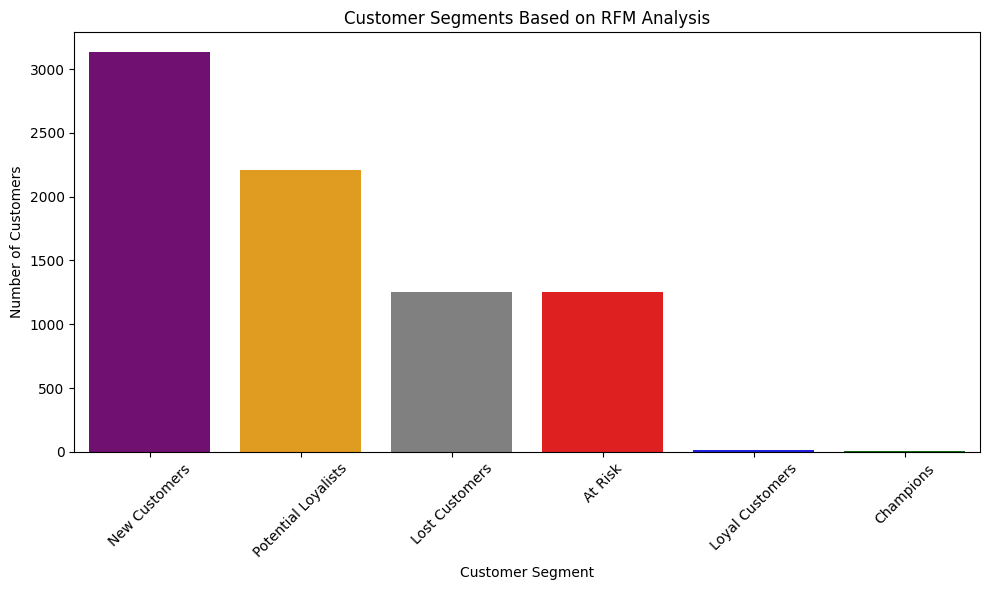

In [40]:
plt.figure(figsize=(10, 6))

colors = {
    'Champions': 'green',
    'Loyal Customers': 'blue',
    'Potential Loyalists': 'orange',
    'New Customers': 'purple',
    'At Risk': 'red',
    'Lost Customers': 'gray'
}

sns.countplot(
    data=rfm,
    x='Segment',
    hue='Segment',
    order=rfm['Segment'].value_counts().index,
    palette=colors,
    legend=False
)

plt.title('Customer Segments Based on RFM Analysis')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [41]:
rfm.to_csv('/content/Zudio_RFM.csv', index=False)

In [42]:
# Cleaned Dataset
df.to_csv("Zudio_Cleaned_Data.csv", index = False)